In [54]:
from deq.p1_strategy import all_metrics_analysis
from deq.plot import p1_delta_bar, p1_line_plot
from deq.deq import ext, deq_col_specs

ext = {
    **ext,
    **deq_col_specs(
        pick_equity_mid=0.03,
        bias_adj_coef=0.5
    ),
    **deq_col_specs(
        pick_equity_mid=0.03,
        bias_adj_coef=0.5,
        deq_loss_factor=0.3,
        suffix="_a"
    ),
    **deq_col_specs(
        pick_equity_mid=0.03,
        bias_adj_coef=0.5,
        deq_loss_factor=0,
        suffix="_b"
    ),
}  

metrics = ["deq", "deq_a", "deq_b"]

# result = all_metrics_analysis(metrics=metrics, results_filter={'lhs': 'format_day', 'op': '>', 'rhs': 2}, extra_ext=ext)
# p1_delta_bar(result, metrics=metrics)
# p1_line_plot(result, metrics=metrics)
# p1_line_plot(result, mode="entropy_loss", metrics=metrics)

In [ ]:
result.agg_df

In [ ]:
early_format = {"lhs": "format_day", "op": "<", "rhs": 13}
res_d1 = all_metrics_analysis(
    metrics=metrics,
    results_filter=early_format,
    metric_filter={"lhs": "format_day", "op": "<", "rhs": 3},
    deq_days=2,
    extra_ext=ext
)

tag_d1 = "Early format using day 2 metrics"
p1_line_plot(res_d1, mode="wr_delta", metrics=metrics, title_extra=tag_d1)
p1_line_plot(res_d1, mode="entropy_loss", metrics=metrics, title_extra=tag_d1)

In [ ]:
res_d1.agg_df

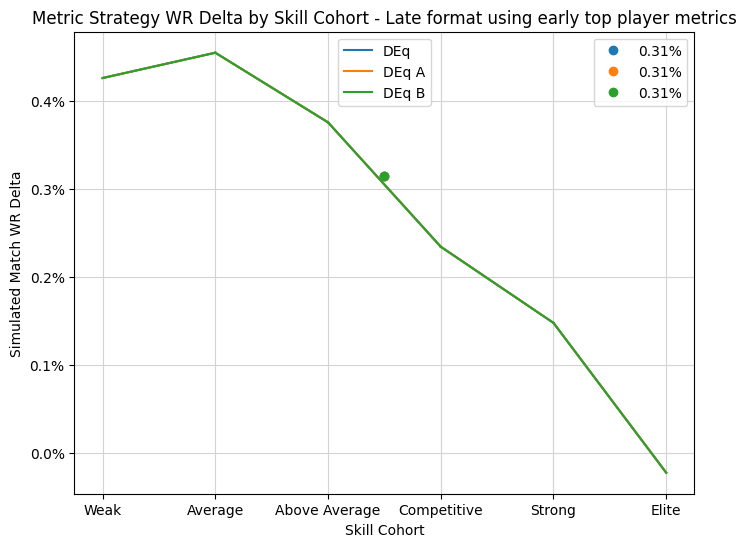

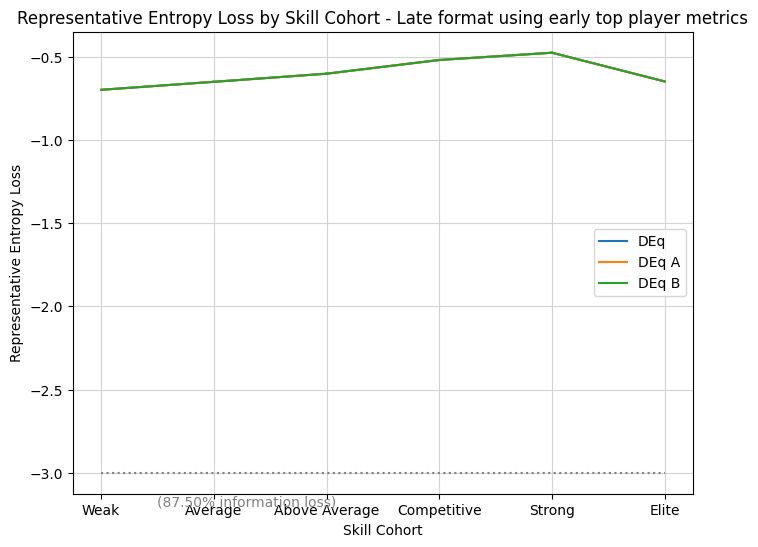

deq_weight,deq_a_weight,deq_b_weight,deq_strat_delta,deq_a_strat_delta,deq_b_strat_delta
f64,f64,f64,f64,f64,f64
6.8678e6,6.8678e6,6.8678e6,0.003138,0.003138,0.003138


In [55]:
early_top = {"$and": [{"player_cohort": "Top"}, early_format]}
late_format = {"$not": early_format}
tag_mid = "Late format using early top player metrics"
res_mid = all_metrics_analysis(
    metric_filter=early_top, results_filter=late_format, deq_days=12, metrics=metrics, extra_ext=ext
)
p1_line_plot(res_mid, mode="wr_delta", metrics=metrics, title_extra=tag_mid)
p1_line_plot(res_mid, mode="entropy_loss", metrics=metrics, title_extra=tag_mid)
res_mid.agg_df

In [64]:
res_mid.metric_results['deq'].mapped_df.select('name', 'expansion', 'deq').unique().filter(pl.col('name') == 'Reprieve')

name,expansion,deq
str,str,f64
"""Reprieve""","""LTR""",0.011093


In [63]:
import polars as pl

In [61]:
res_mid.metric_results['deq_a'].mapped_df.select('name', 'expansion', 'deq_a').unique()

name,expansion,deq_a
str,str,f64
"""Lotuslight Dancers""","""TDM""",0.017303
"""Reprieve""","""LTR""",0.011093
"""Eaten by Piranhas""","""LCI""",0.009293
"""Frolicking Familiar""","""WOE""",0.007935
"""Jolted Awake""","""MH3""",0.003159
…,…,…
"""Frodo, Sauron's Bane""","""LTR""",0.027588
"""Hard-Hitting Question""","""MKM""",0.019745
"""Nightshade Dryad""","""MH3""",0.028137
